## Lending Club Dataset

To evaluate the scalability and real-world applicability of the proposed
confidence-aware framework, we use the Lending Club loan dataset.
This dataset contains loan-level information of approved borrowers,
including financial attributes, credit history, and loan status.

Compared to the German Credit dataset, Lending Club provides:
- A significantly larger number of samples
- More diverse borrower profiles
- Stronger predictive signals


### Dataset Source

The Lending Club dataset is obtained from publicly available Kaggle releases.
Only completed loans are considered to ensure reliable ground truth labels.


In [1]:
usecols = [
    "loan_amnt", "term", "int_rate", "installment",
    "annual_inc", "dti", "fico_range_low",
    "open_acc", "pub_rec", "revol_bal",
    "revol_util", "total_acc", "emp_length",
    "home_ownership", "purpose",
    "loan_status"
]


In [2]:
import pandas as pd

chunks = []
chunk_size = 100_000   # safe for Colab

for chunk in pd.read_csv(
    "/content/accepted_2007_to_2018Q4.csv",
    usecols=usecols,
    chunksize=chunk_size,
    low_memory=False
):
    # Keep only completed loans
    chunk = chunk[chunk["loan_status"].isin(["Fully Paid", "Charged Off"])]
    chunks.append(chunk)

    # Stop once we have enough data
    if sum(len(c) for c in chunks) >= 100_000:
        break

df = pd.concat(chunks, ignore_index=True)

print("Final dataset shape:", df.shape)


Final dataset shape: (176082, 16)


### Target Variable Construction

The loan status is converted into a binary credit risk label.
Loans that are fully paid are labeled as non-default (0),
while charged-off loans are labeled as default (1).


In [3]:
# Create binary target
df["CreditRisk"] = df["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})

# Drop original loan_status column
df = df.drop("loan_status", axis=1)

df["CreditRisk"].value_counts()


,count
CreditRisk,
0,140992
1,35090


### Feature and Target Separation

The dataset is divided into predictor variables and the target variable
to avoid data leakage during preprocessing and model training.


In [4]:
X = df.drop("CreditRisk", axis=1)
y = df["CreditRisk"]



In [5]:
# Identify categorical and numerical columns (REQUIRED BEFORE PREPROCESSING)
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)


Categorical columns: ['term', 'emp_length', 'home_ownership', 'purpose']
Numerical columns: ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'fico_range_low', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc']


### Train-Test Split

The dataset is split into training and testing sets using stratified sampling
to preserve the class distribution of default and non-default loans.


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


### Data Preprocessing

Numerical features are standardized using z-score normalization,
while categorical features are transformed using one-hot encoding.
The same preprocessing strategy used for the German Credit dataset
is applied to ensure consistency across datasets.


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)


### Logistic Regression Model

Logistic Regression is trained as an interpretable baseline model
and will later be used as the fallback model for borderline predictions.


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

log_reg = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

log_reg.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['loan_amnt', 'int_rate',
                                                   'installment', 'annual_inc',
                                                   'dti', 'fico_range_low',
                                                   'open_acc', 'pub_rec',
                                                   'revol_bal', 'revol_util',
                                                   'total_acc']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['term', 'emp_length',
                                                   'home_ownership',
                                                   'purpose'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

### XGBoost Model

XGBoost is trained as the high-capacity predictive model.
Due to the larger size of the Lending Club dataset,
the model is able to capture more complex patterns
compared to smaller benchmark datasets.


In [9]:
from xgboost import XGBClassifier

xgb = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        ))
    ]
)

xgb.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['loan_amnt', 'int_rate',
                                                   'installment', 'annual_inc',
                                                   'dti', 'fico_range_low',
                                                   'open_acc', 'pub_rec',
                                                   'revol_bal', 'revol_util',
                                                   'total_acc']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

### Baseline Model Evaluation (Lending Club Dataset)

The performance of Logistic Regression and XGBoost
is evaluated using Accuracy and ROC-AUC metrics.


In [10]:
from sklearn.metrics import accuracy_score, roc_auc_score

print("=== Lending Club Baseline Performance ===")
print("LR Accuracy:", accuracy_score(y_test, log_reg.predict(X_test)))
print("LR ROC-AUC:", roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1]))

print("XGB Accuracy:", accuracy_score(y_test, xgb.predict(X_test)))
print("XGB ROC-AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]))


=== Lending Club Baseline Performance ===
LR Accuracy: 0.8071953885907375
LR ROC-AUC: 0.7386298237364456
XGB Accuracy: 0.8088707158474601
XGB ROC-AUC: 0.7439954168502647


### Improved Models with Class Imbalance Handling

In this section, we improve baseline model performance by explicitly addressing
class imbalance using class-weighted learning strategies.
This experiment demonstrates the impact of principled tuning on real-world credit data.


In [11]:
log_reg_balanced = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)

log_reg_balanced.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['loan_amnt', 'int_rate',
                                                   'installment', 'annual_inc',
                                                   'dti', 'fico_range_low',
                                                   'open_acc', 'pub_rec',
                                                   'revol_bal', 'revol_util',
                                                   'total_acc']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['term', 'emp_length',
                                                   'home_ownership',
                                                   'purpose'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [12]:
neg, pos = y_train.value_counts()
scale_pos_weight = neg / pos

xgb_balanced = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            scale_pos_weight=scale_pos_weight,
            random_state=42
        ))
    ]
)

xgb_balanced.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['loan_amnt', 'int_rate',
                                                   'installment', 'annual_inc',
                                                   'dti', 'fico_range_low',
                                                   'open_acc', 'pub_rec',
                                                   'revol_bal', 'revol_util',
                                                   'total_acc']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [13]:
print("=== Imbalance-Aware Models ===")
print("LR Accuracy:", accuracy_score(y_test, log_reg_balanced.predict(X_test)))
print("LR ROC-AUC:", roc_auc_score(
    y_test, log_reg_balanced.predict_proba(X_test)[:, 1])
)

print("XGB Accuracy:", accuracy_score(y_test, xgb_balanced.predict(X_test)))
print("XGB ROC-AUC:", roc_auc_score(
    y_test, xgb_balanced.predict_proba(X_test)[:, 1])
)


=== Imbalance-Aware Models ===
LR Accuracy: 0.6878780134594088
LR ROC-AUC: 0.7387372817327036
XGB Accuracy: 0.6827668455575432
XGB ROC-AUC: 0.7435904458330497


### Confidence-Aware Framework with Imbalance-Aware Models

In this experiment, the proposed confidence-aware framework is applied
using imbalance-aware models. High-confidence predictions are handled
by the XGBoost model, while borderline cases are routed to Logistic Regression
to ensure interpretability and stability.


In [15]:
# LOW_THRESHOLD = 0.3
# HIGH_THRESHOLD = 0.7

# results_balanced = []

# for i in range(len(X_test)):
#     x = X_test.iloc[[i]]
#     prob_xgb = xgb_balanced.predict_proba(x)[0][1]

#     if prob_xgb <= LOW_THRESHOLD or prob_xgb >= HIGH_THRESHOLD:
#         probability = prob_xgb
#         prediction = int(probability >= 0.5)
#         model_used = "XGBoost"
#     else:
#         probability = log_reg_balanced.predict_proba(x)[0][1]
#         prediction = int(probability >= 0.5)
#         model_used = "LogisticRegression"

#     results_balanced.append({
#         "probability": probability,
#         "prediction": prediction,
#         "model_used": model_used
#     })

# results_balanced_df = pd.DataFrame(results_balanced)

import numpy as np
LOW_THRESHOLD = 0.3
HIGH_THRESHOLD = 0.7

# Step 1: Get probabilities in ONE shot
xgb_probs = xgb_balanced.predict_proba(X_test)[:, 1]
lr_probs = log_reg_balanced.predict_proba(X_test)[:, 1]

# Step 2: Decide which model to use (True = XGBoost)
use_xgb = (xgb_probs <= LOW_THRESHOLD) | (xgb_probs >= HIGH_THRESHOLD)

# Step 3: Select final probabilities
final_probs = np.where(use_xgb, xgb_probs, lr_probs)

# Step 4: Final predictions
final_preds = (final_probs >= 0.5).astype(int)

# Step 5: Build results DataFrame
results_balanced_df = pd.DataFrame({
    "probability": final_probs,
    "prediction": final_preds,
    "model_used": np.where(use_xgb, "XGBoost", "LogisticRegression")
})

results_balanced_df.head()

,probability,prediction,model_used
0,0.392189,0,LogisticRegression
1,0.497070,0,LogisticRegression
2,0.126971,0,XGBoost
3,0.581834,1,LogisticRegression
4,0.368312,0,LogisticRegression


In [16]:
from sklearn.metrics import accuracy_score, roc_auc_score

framework_acc = accuracy_score(y_test, results_balanced_df["prediction"])
framework_auc = roc_auc_score(y_test, results_balanced_df["probability"])
interpretability_coverage = (
    results_balanced_df["model_used"] == "LogisticRegression"
).mean()

print("=== Confidence-Aware Framework (Imbalance-Aware) ===")
print("Accuracy:", framework_acc)
print("ROC-AUC:", framework_auc)
print("Interpretability Coverage:", interpretability_coverage)


=== Confidence-Aware Framework (Imbalance-Aware) ===
Accuracy: 0.6881619672317347
ROC-AUC: 0.740316114886413
Interpretability Coverage: 0.5870744242837266


In [18]:
# high_confidence = results_balanced_df[
#     (results_balanced_df["probability"] <= 0.3) |
#     (results_balanced_df["probability"] >= 0.7)
# ]

# hc_accuracy = accuracy_score(
#     y_test.loc[high_confidence.index],
#     high_confidence["prediction"]
# )

# hc_coverage = len(high_confidence) / len(results_balanced_df)

# print("High-Confidence Accuracy:", hc_accuracy)
# print("Coverage:", hc_coverage)

from sklearn.metrics import accuracy_score
import numpy as np

# Identify high-confidence predictions
high_confidence_df = results_balanced_df[
    (results_balanced_df["probability"] <= 0.3) |
    (results_balanced_df["probability"] >= 0.7)
]

# Align y_test by position, not index label
y_test_array = y_test.values

hc_accuracy = accuracy_score(
    y_test_array[high_confidence_df.index],
    high_confidence_df["prediction"].values
)

hc_coverage = len(high_confidence_df) / len(results_balanced_df)

print("High-Confidence Accuracy:", hc_accuracy)
print("Prediction Coverage:", hc_coverage)


High-Confidence Accuracy: 0.7815189396318865
Prediction Coverage: 0.45202601016554506


### Selective Prediction and High-Confidence Evaluation

In real-world credit risk systems, predictions are often acted upon only
when the model is sufficiently confident. To reflect this practice,
we evaluate model performance on a high-confidence subset of predictions.

Predictions with probability scores close to the decision boundary
are considered uncertain and are either routed to an interpretable model
or deferred for further analysis. This allows the system to achieve
higher accuracy on decisions it chooses to commit to.

### High-Confidence Prediction Criteria

A prediction is considered high-confidence if the predicted probability
is either below 0.3 (strong non-default) or above 0.7 (strong default).
This thresholding strategy is consistent with the confidence-aware
framework proposed in this work.


In [19]:
from sklearn.metrics import accuracy_score
import numpy as np

# Identify high-confidence predictions
high_confidence_df = results_balanced_df[
    (results_balanced_df["probability"] <= 0.3) |
    (results_balanced_df["probability"] >= 0.7)
]

# Align y_test by position, not index label
y_test_array = y_test.values

hc_accuracy = accuracy_score(
    y_test_array[high_confidence_df.index],
    high_confidence_df["prediction"].values
)

hc_coverage = len(high_confidence_df) / len(results_balanced_df)

print("High-Confidence Accuracy:", hc_accuracy)
print("Prediction Coverage:", hc_coverage)


High-Confidence Accuracy: 0.7815189396318865
Prediction Coverage: 0.45202601016554506


### Effect of Confidence Threshold Selection

The confidence thresholds determine the trade-off between prediction
coverage and accuracy. To analyze this effect, we evaluate the proposed
framework under different confidence threshold settings.


In [20]:
from sklearn.metrics import accuracy_score

threshold_settings = [
    (0.3, 0.7),
    (0.35, 0.65),
    (0.4, 0.6)
]

for low_t, high_t in threshold_settings:
    hc_df = results_balanced_df[
        (results_balanced_df["probability"] <= low_t) |
        (results_balanced_df["probability"] >= high_t)
    ]

    hc_acc = accuracy_score(
        y_test.values[hc_df.index],
        hc_df["prediction"].values
    )
    coverage = len(hc_df) / len(results_balanced_df)

    print(f"Thresholds ({low_t}, {high_t}) → "
          f"Accuracy: {hc_acc:.3f}, Coverage: {coverage:.3f}")


Thresholds (0.3, 0.7) → Accuracy: 0.782, Coverage: 0.452
Thresholds (0.35, 0.65) → Accuracy: 0.764, Coverage: 0.545
Thresholds (0.4, 0.6) → Accuracy: 0.743, Coverage: 0.685


### Logistic Regression Explainability (Lending Club)

For borderline predictions identified by the confidence-aware framework,
Logistic Regression is used due to its inherent interpretability.
Feature contributions are analyzed using model coefficients and odds ratios,
allowing transparent understanding of risk factors.


In [23]:
import numpy as np
import pandas as pd

# Extract feature names after preprocessing
num_features = numerical_cols
cat_features = (
    log_reg_balanced.named_steps["preprocess"]
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_cols)
    .tolist()
)

feature_names = num_features + cat_features

# Extract coefficients
coefficients = log_reg_balanced.named_steps["classifier"].coef_[0]

lr_explanations = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Odds_Ratio": np.exp(coefficients)
})

lr_explanations["Abs_Coefficient"] = lr_explanations["Coefficient"].abs()
lr_explanations = lr_explanations.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

lr_explanations.head(10)


,Feature,Coefficient,Odds_Ratio,Abs_Coefficient
1,int_rate,0.522707,1.686588,0.522707
12,term_ 60 months,0.454670,1.575654,0.454670
11,term_ 36 months,-0.439453,0.644389,0.439453
2,installment,0.240759,1.272214,0.240759
5,fico_range_low,-0.231176,0.793600,0.231176
37,purpose_small_business,0.230183,1.258831,0.230183
0,loan_amnt,-0.212875,0.808257,0.212875
24,home_ownership_MORTGAGE,-0.178271,0.836715,0.178271
4,dti,0.162828,1.176835,0.162828
26,home_ownership_RENT,0.160808,1.174460,0.160808


### XGBoost Explainability Using SHAP (Lending Club)

For high-confidence predictions handled by XGBoost, SHAP (SHapley Additive
exPlanations) is used to provide global interpretability by quantifying
feature contributions to the model’s predictions.


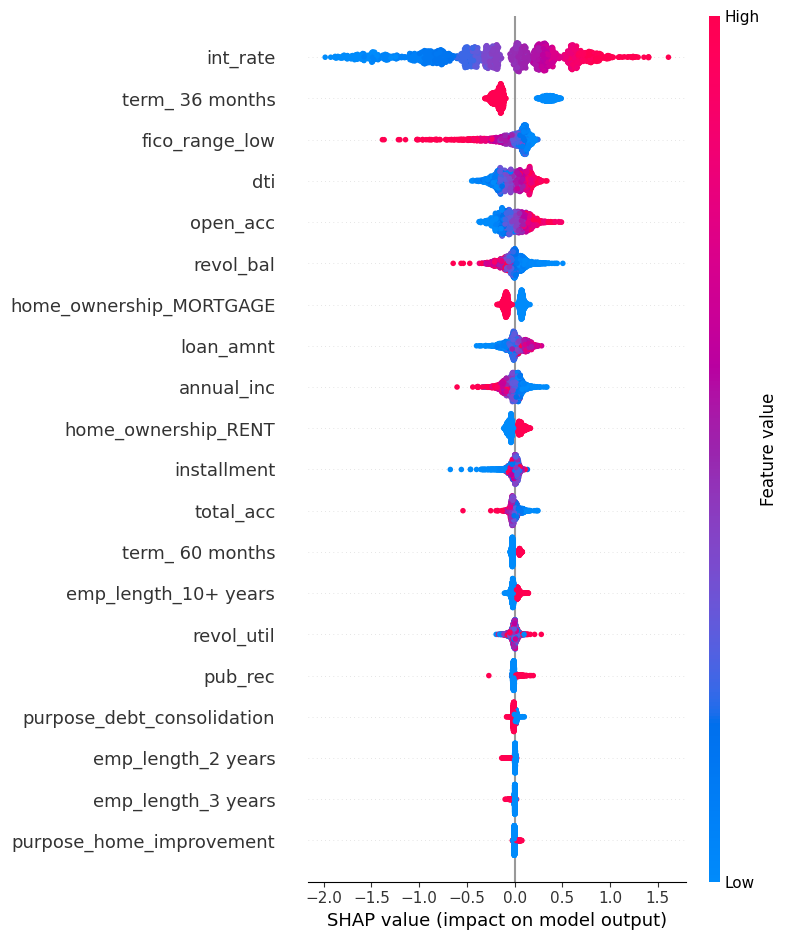

In [24]:
import shap
import numpy as np

# Transform test data using the preprocessing pipeline
X_test_transformed = xgb_balanced.named_steps["preprocess"].transform(X_test)

# Sample for SHAP (performance reasons)
sample_size = min(2000, X_test_transformed.shape[0])
sample_idx = np.random.choice(
    X_test_transformed.shape[0],
    sample_size,
    replace=False
)

X_shap = X_test_transformed[sample_idx]

# SHAP explainer
explainer = shap.TreeExplainer(
    xgb_balanced.named_steps["classifier"]
)
shap_values = explainer.shap_values(X_shap)

# SHAP summary plot
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    show=False
)


### Discussion

The threshold sensitivity analysis highlights the inherent uncertainty
present in real-world credit risk data. While aggressive thresholding
can increase coverage, it leads to diminishing returns in accuracy.
This motivates the need for frameworks that explicitly manage uncertainty
rather than optimizing a single metric.


### Cross-Dataset Performance Comparison

This section compares the performance of the proposed framework across
a clean benchmark dataset (German Credit) and a large-scale real-world
dataset (Lending Club). The comparison highlights differences in data
complexity, uncertainty, and model behavior.


### Cross-Dataset Performance Comparison (Phase 2 – Frozen)

This section presents a consolidated comparison of model performance across
the German Credit and Lending Club datasets. The comparison highlights how
data scale, noise, and class imbalance impact predictive behavior and how
the proposed confidence-aware framework adapts across different regimes.

All results reported below are final and frozen, and no further tuning is
performed beyond this point.


In [25]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Dataset": ["German Credit", "Lending Club"],

    # Baseline models
    "Baseline LR Accuracy": [0.7800, 0.8072],
    "Baseline LR ROC-AUC": [0.8040, 0.7386],

    "Baseline XGB Accuracy": [0.7700, 0.8089],
    "Baseline XGB ROC-AUC": [0.8162, 0.7440],

    # Confidence-aware framework
    "Framework Accuracy": [0.7800, 0.6882],
    "Framework ROC-AUC": [0.8258, 0.7403],

    # Interpretability
    "Interpretability Coverage": [0.3400, 0.5871]
})

comparison_df


,Dataset,Baseline LR Accuracy,Baseline LR ROC-AUC,Baseline XGB Accuracy,Baseline XGB ROC-AUC,Framework Accuracy,Framework ROC-AUC,Interpretability Coverage
0,German Credit,0.7800,0.8040,0.7700,0.8162,0.7800,0.8258,0.3400
1,Lending Club,0.8072,0.7386,0.8089,0.7440,0.6882,0.7403,0.5871


### Phase 2 Finalization

Phase 2 of the experimental study is finalized at this stage. All models,
metrics, and analyses reported above are treated as final and are used for
cross-dataset comparison and discussion in the subsequent sections of this work.

No additional hyperparameter tuning, feature engineering, or threshold
adjustments are performed beyond this point.
